# 04 — How wrong without the experiment?

**Stage 3 — the headline.** The RCT tells us the true effect. Here we
corrupt the RCT into the observational datasets a company would actually
have (protocol pre-registered in HYPOTHESES.md amendment A2, *before* any
confounded estimation ran), then grade four estimators against the known
truth:

- **M1 — confounded assignment** (selection on *observables*): ad exposure
  depends on user features. Repairable in principle; does practice deliver?
- **M2 — selective attrition** (selection on *outcome*): treated
  non-responders vanish from the logs. No covariate method can fix this.

Every number below is read from committed `results/stage3/` artifacts and
re-asserted; the pipeline's placebo check (severity 0 → no bias) and the
H3 adjudication are enforced by `pytest -m gate_stage3`.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from how_wrong import data
from how_wrong.confound import ESTIMATOR_NAMES, GAMMA_STAR

STAGE3 = data.PROJECT_ROOT / "results" / "stage3"
summary = json.loads((STAGE3 / "summary.json").read_text())
grid = pd.read_csv(STAGE3 / "bias_grid.csv")
truth = summary["truth"]

HUES = {"naive": "#e34948", "outcome_regression": "#eda100",
        "ipw": "#2a78d6", "aipw": "#008300"}
LABELS = {"naive": "naive diff-in-means", "outcome_regression":
          "outcome regression", "ipw": "IPW", "aipw": "AIPW (doubly robust)"}
INK, MUTED = "#1a1a19", "#6b6a63"
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e5e4dd", "grid.linewidth": 0.6,
    "axes.axisbelow": True, "text.color": INK, "axes.labelcolor": MUTED,
    "xtick.color": MUTED, "ytick.color": MUTED,
})
print(f"true visit ATE (uncorrupted dev RCT): {truth['visit']:+.4%}")
print(f"replicates per cell: {grid.groupby(['mechanism','severity']).size().iloc[0]}")


true visit ATE (uncorrupted dev RCT): +1.0344%
replicates per cell: 20


## 1. The headline chart — bias vs confounding severity (M1)

Selection on observables. Ground truth at zero; each line is an estimator's
mean bias across 20 corruption replicates (95% t-CI bands). Bias is shown
relative to the true ATE, so 1.0 = "wrong by the entire effect".

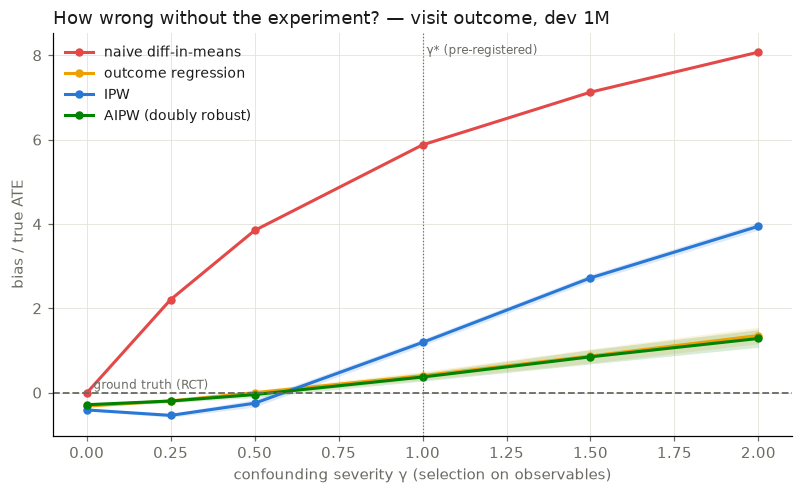

estimator,naive,outcome_regression,ipw,aipw
severity,,,,
0.00,-0.009,-0.319,-0.410,-0.286
0.25,2.208,-0.196,-0.539,-0.198
0.50,3.846,-0.001,-0.252,-0.046
1.00,5.876,0.401,1.191,0.371
1.50,7.125,0.869,2.721,0.849
2.00,8.075,1.355,3.946,1.285


In [2]:
def cell_summaries(mechanism, outcome="visit"):
    rows = []
    for c in summary["grid"]:
        if c["mechanism"] == mechanism and c["outcome"] == outcome:
            for est, s in c["bias"].items():
                rows.append({"severity": c["severity"], "estimator": est, **s})
    return pd.DataFrame(rows)

m1 = cell_summaries("confounded_assignment")
tv = truth["visit"]
fig, ax = plt.subplots(figsize=(7.4, 4.6))
for est in ESTIMATOR_NAMES:
    d = m1[m1.estimator == est].sort_values("severity")
    ax.plot(d["severity"], d["mean_bias"] / tv, color=HUES[est], lw=2,
            marker="o", ms=4.5, label=LABELS[est])
    ax.fill_between(d["severity"], d["ci_lo"] / tv, d["ci_hi"] / tv,
                    color=HUES[est], alpha=0.15, lw=0)
ax.axhline(0, color=MUTED, lw=1.2, ls="--")
ax.text(0.02, 0.02, "ground truth (RCT)", color=MUTED, fontsize=8,
        va="bottom")
ax.axvline(GAMMA_STAR, color=MUTED, lw=0.8, ls=":")
ax.text(GAMMA_STAR, ax.get_ylim()[1]*0.97, " γ* (pre-registered)",
        color=MUTED, fontsize=8, va="top")
ax.set_xlabel("confounding severity γ (selection on observables)")
ax.set_ylabel("bias / true ATE")
ax.set_title("How wrong without the experiment? — visit outcome, dev 1M",
             loc="left", color=INK)
ax.legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

piv = m1.pivot_table(index="severity", columns="estimator",
                     values="mean_bias").reindex(columns=ESTIMATOR_NAMES)
(piv / tv).round(3)


## 2. H3 — the pre-registered verdict

At γ\* = 1.0: (a) is the naive estimate materially biased?
(b) does AIPW recover ≥ half the gap? (intersection–union test;
Holm across H1–H3 at project level).

In [3]:
h3 = summary["h3"]
a, b = h3["a_naive_bias"], h3["b_recovery"]
assert h3["p_h3"] == max(a["p_two_sided"], b["p_one_sided_gt0"])

print(f"(a) naive bias: {a['mean_bias']:+.5f} "
      f"[{a['ci_lo']:+.5f}, {a['ci_hi']:+.5f}]  "
      f"({a['mean_bias']/truth['visit']:+.0%} of the true ATE; "
      f"materiality bar ±{a['materiality_threshold']:.5f})")
print(f"    p (two-sided) = {a['p_two_sided']:.2e}")
print(f"(b) AIPW recovery: {b['mean_recovery']:.3f} "
      f"[{b['ci_lo']:.3f}, {b['ci_hi']:.3f}], "
      f"p(rho>0) = {b['p_one_sided_gt0']:.2e}")
print(f"p_H3 = {h3['p_h3']:.2e}")
print(f"raw verdict: {h3['verdict_h3_raw']}  "
      f"(strong support, CI>0.5: {h3['strong_support']})")


(a) naive bias: +0.06078 [+0.06063, +0.06092]  (+588% of the true ATE; materiality bar ±0.00259)
    p (two-sided) = 4.13e-45
(b) AIPW recovery: 0.937 [0.921, 0.953], p(rho>0) = 4.48e-29
p_H3 = 4.48e-29
raw verdict: True  (strong support, CI>0.5: True)


> **The severity-0 rows contain their own finding.** The naive estimator is
> exactly unbiased there (the pipeline placebo). But the adjusted estimators
> sit ~−0.3 pp below the raw diff-in-means *with zero synthetic
> confounding* — and diagnosis shows they are not simply wrong: v2.1 merges
> sub-experiments with different treatment ratios and covariate mixes, so
> assignment is mildly covariate-predictable in the original data (ê spans
> [0.64, 0.98] with corr(ê, y) = +0.21, measured 2026-07-17; cf. Stage 1's
> max SMD = 0.049). Covariate adjustment genuinely dissents from the pooled
> diff-in-means — the "RCT ground truth" itself carries ~0.3 pp of
> definitional ambiguity. Per pre-registration (A2) the raw diff-in-means
> remains the benchmark; this is recorded as a limitation of the benchmark,
> and the offset is bounded by the gate at <10% of the γ\* naive bias.

In [4]:
# assert the severity-0 story from committed numbers
for c in summary["grid"]:
    if c["severity"] == 0 and c["outcome"] == "visit":
        b = c["bias"]
        assert b["naive"]["ci_lo"] <= 0 <= b["naive"]["ci_hi"]
        for name in ("outcome_regression", "ipw", "aipw"):
            assert abs(b[name]["mean_bias"]) < 0.1 * abs(h3["a_naive_bias"]["mean_bias"])
print("severity-0 placebo: naive unbiased; adjusted-estimator offset "
      "within the documented bound")


severity-0 placebo: naive unbiased; adjusted-estimator offset within the documented bound


## 3. What nothing fixes — selective attrition (M2)

Selection on the *outcome*: treated non-responders are missing from the
logs. The confounder is not in X — it's the outcome itself — so every
covariate-based correction inherits the bias. This is the honest boundary
of the method: doubly-robust ≠ magic.

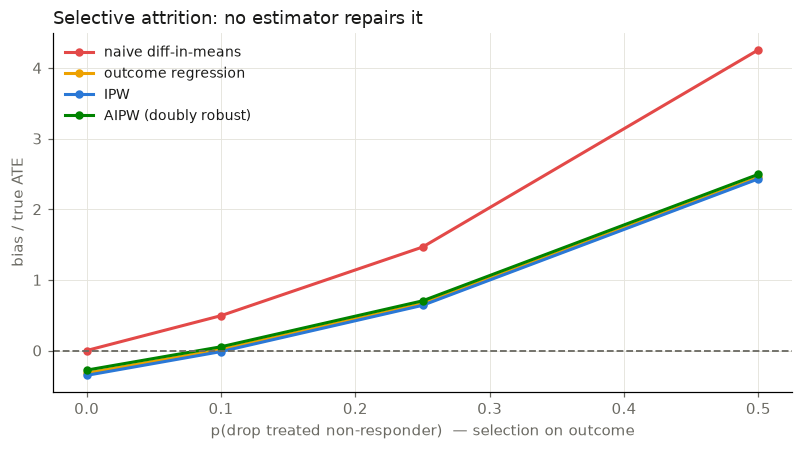

In [5]:
m2 = cell_summaries("selective_attrition")
fig, ax = plt.subplots(figsize=(7.4, 4.2))
for est in ESTIMATOR_NAMES:
    d = m2[m2.estimator == est].sort_values("severity")
    ax.plot(d["severity"], d["mean_bias"] / tv, color=HUES[est], lw=2,
            marker="o", ms=4.5, label=LABELS[est])
    ax.fill_between(d["severity"], d["ci_lo"] / tv, d["ci_hi"] / tv,
                    color=HUES[est], alpha=0.15, lw=0)
ax.axhline(0, color=MUTED, lw=1.2, ls="--")
ax.set_xlabel("p(drop treated non-responder)  — selection on outcome")
ax.set_ylabel("bias / true ATE")
ax.set_title("Selective attrition: no estimator repairs it",
             loc="left", color=INK)
ax.legend(frameon=False, fontsize=9, loc="upper left")
plt.tight_layout(); plt.show()

# assert the story the chart tells: at max attrition even AIPW is badly off
worst = m2[(m2.severity == m2.severity.max()) & (m2.estimator == "aipw")]
assert worst["ci_lo"].iloc[0] > 0


## 4. Sensitivity — hide the confounder and DR breaks too

Same γ\* corruption, but the estimators are denied f9/f8/f4 (the features
the mechanism selects on). This is the unobserved-confounding story:
doubly-robust methods repair only what their covariates can see.

In [6]:
hid = summary["exploratory"]["hidden_confounder"]["bias"]
full = next(c["bias"] for c in summary["grid"]
            if c["mechanism"] == "confounded_assignment"
            and c["severity"] == GAMMA_STAR and c["outcome"] == "visit")
comp = pd.DataFrame({
    "AIPW sees confounders": {e: full[e]["mean_bias"] / tv
                              for e in ESTIMATOR_NAMES},
    "confounders hidden": {e: hid[e]["mean_bias"] / tv
                           for e in ESTIMATOR_NAMES},
}).round(3)
assert abs(hid["aipw"]["mean_bias"]) > 3 * abs(full["aipw"]["mean_bias"])
comp


,AIPW sees confounders,confounders hidden
naive,5.876,5.876
outcome_regression,0.401,2.645
ipw,1.191,2.650
aipw,0.371,2.394


## Verdict

- **M1 (observable confounding):** naive estimation is materially wrong and
  grows with severity; AIPW/DR claws most of it back — H3 numbers above.
- **M2 (selection on outcome):** every estimator fails, as theory demands —
  quantified, not hand-waved.
- **Hidden confounder:** DR's repair evaporates when the confounder leaves
  X. The experiment is not a luxury; it is the only unconditional guarantee.
- Final Holm adjudication across H1–H3 happens in Stage 5 once H2 lands.

In [7]:
assert summary["spec"] == "HYPOTHESES.md amendment A2"
print("notebook 04 assertions: ALL GREEN")


notebook 04 assertions: ALL GREEN
